In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

from dotenv import load_dotenv
import os
load_dotenv()
YOUR_HF_TOKEN = os.getenv("YOUR_HF_TOKEN")

/home/bistreamt/Desktop/master/research 3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'respins': 416, 'inadmisibil': 588, 'admis': 396}


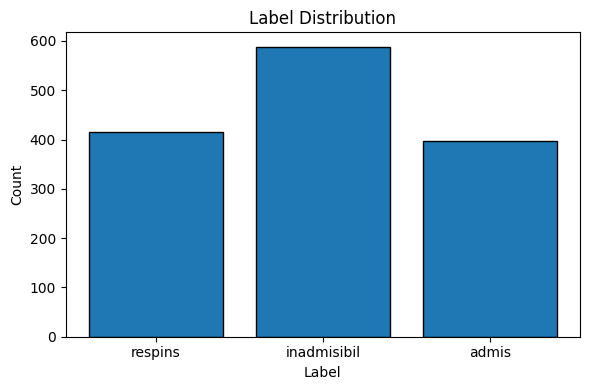

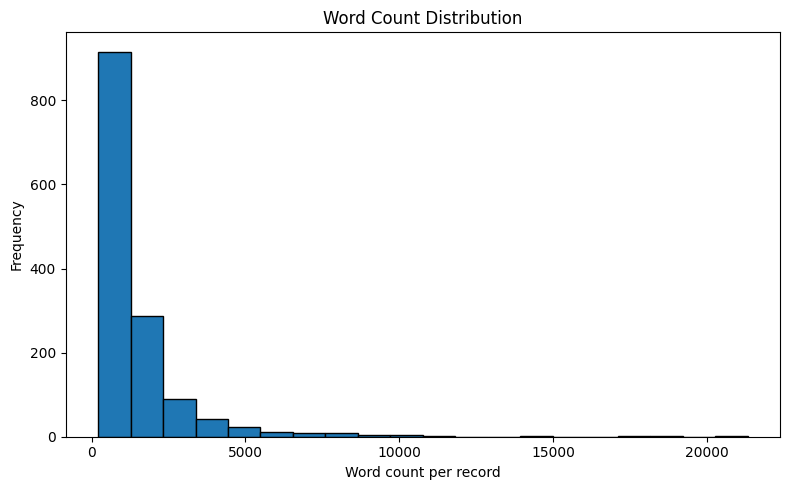

Total records: 1400


In [2]:
# json_file = "data-clean.json"
json_file = "data/supreme-court-data.json"

with open(json_file, 'r') as f:
    data = json.load(f)

# data = [item for item in data if item['label'] != 'inadmisibil']

labels = [item['label'] for item in data]
label_counts = {}
for label in labels:
    label_counts[label] = label_counts.get(label, 0) + 1

print(label_counts)

# print(f"Total unique labels: {len(label_counts)}")

plt.figure(figsize=(6, 4))
plt.bar(label_counts.keys(), label_counts.values(), edgecolor="black")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.tight_layout()
plt.show()
plt.close()

word_counts = []
for item in data:
    texts = [v for v in item.values() if isinstance(v, str)]
    combined = " ".join(texts)
    word_counts.append(len(combined.split()))

plt.figure(figsize=(8, 5))
plt.hist(word_counts, bins=20, edgecolor="black")
plt.xlabel("Word count per record")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")
plt.tight_layout()
plt.show()
plt.close() 

print(f"Total records: {len(data)}")


In [3]:
arr = np.array(word_counts)

mean = arr.mean()
median = np.median(arr)
std = arr.std(ddof=0)  # population std
p90, p95, p99 = np.percentile(arr, [90, 95, 99])

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std (population): {std:.2f}")
print(f"P90: {p90:.0f}")
print(f"P95: {p95:.0f}")
print(f"P99: {p99:.0f}")

Mean: 1506.18
Median: 1008.00
Std (population): 1728.00
P90: 2763
P95: 4278
P99: 8654


{'vinovat': 5244, 'nevinovat': 3626}
Total unique labels: 2


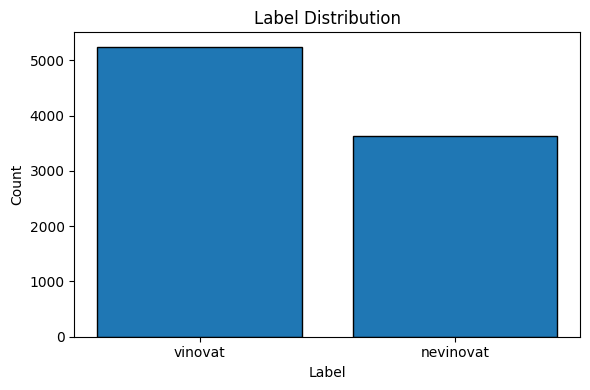

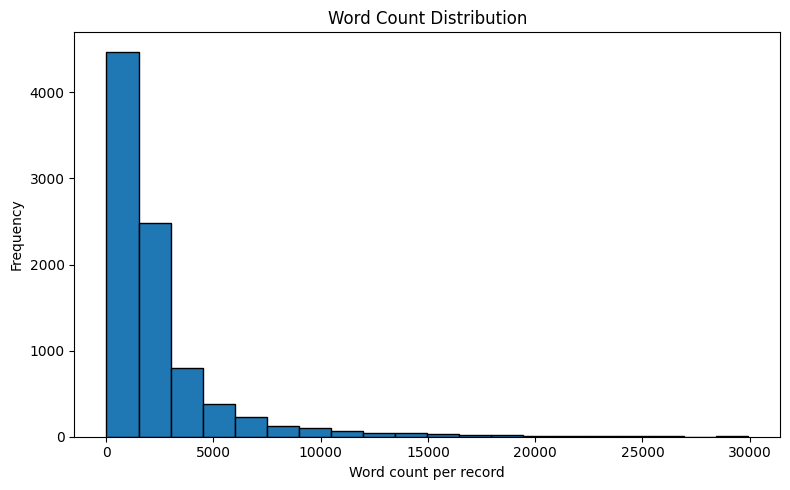

Total records: 8870
Mean: 2475.80
Median: 1502.00
Std (population): 3052.41
P90: 5366
P95: 8139
P99: 16244


In [6]:
json_file = "data/regional-court-data.json"

with open(json_file, 'r') as f:
    data = json.load(f)

labels = [item['label'] for item in data]
label_counts = {}
for label in labels:
    label_counts[label] = label_counts.get(label, 0) + 1

print(label_counts)

print(f"Total unique labels: {len(label_counts)}")

plt.figure(figsize=(6, 4))
plt.bar(label_counts.keys(), label_counts.values(), edgecolor="black")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.tight_layout()
plt.show()
plt.close()

word_counts = []
for item in data:
    texts = [v for v in item.values() if isinstance(v, str)]
    combined = " ".join(texts)
    word_counts.append(len(combined.split()))

plt.figure(figsize=(8, 5))
plt.hist(word_counts, bins=20, edgecolor="black")
plt.xlabel("Word count per record")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")
plt.tight_layout()
plt.show()
plt.close() 

print(f"Total records: {len(data)}")

arr = np.array(word_counts)

mean = arr.mean()
median = np.median(arr)
std = arr.std(ddof=0)  # population std
p90, p95, p99 = np.percentile(arr, [90, 95, 99])

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std (population): {std:.2f}")
print(f"P90: {p90:.0f}")
print(f"P95: {p95:.0f}")
print(f"P99: {p99:.0f}")

In [15]:
# Find up to 5 guilty ("vinovat") cases with word count between 310 and 330

def combined_text(item):
    return " ".join(v for v in item.values() if isinstance(v, str)).strip()

matches = []
for idx, item in enumerate(data):
    if str(item.get("label", "")).lower() == "vinovat":
        txt = combined_text(item)
        wc = len(txt.split())
        if 310 <= wc <= 330:
            matches.append((idx, item, wc, txt))
        if len(matches) == 5:
            break

if not matches:
    print("No guilty cases found in the 310-330 word range.")
else:
    print(f"Found {len(matches)} case(s):\n")
    for idx, item, wc, txt in matches:
        print(f"INDEX: {idx}")
        print(f"SOURCE: {item.get('source_path')}")
        print(f"WORD COUNT: {wc}")
        print(txt)
        print("-" * 80)

Found 3 case(s):

INDEX: 49
SOURCE: cases\1_1\46-21-1339-04052012.pdf
WORD COUNT: 312
Prin sentinţa Judecătoriei Bălți din 29.05.2008 a fost condamnat C. F.A., în baza art.151 alin.(1) CP la 5 ani închisoare, cu executarea pedepsei în penitenciar de tip închis. Condamnatul este deţinut în Penitenciarul nr.6 din or.Soroca. C. F. A. s-a adresat cu o plângere privind anularea sancţiunii disciplinare aplicate, pe care o consideră ilegală. În şedinţa de judecată, condamnatul şi-a susţinut cererea, solicitînd anularea sancţiunii disciplinare sub formă de mustrare aplicate prin decizia şefului Penitenciarului nr. 6 din 17.01.2012, pentru faptul că la locul de dormit a fost ridicat un încărcător de la telefonul mobil. Procurorul a pledat pentru respingerea cererii, din motivul că referitor la faptul dat s-a expus judecătorul de instrucţie prin încheierea din 25.04.2012, în cadrul examinării cererii condamnatului. Cererea a fost admisă, cu anularea sancţiunii disciplinare sub formă de mustrare,

In [47]:
import matplotlib.pyplot as plt
from textwrap import fill

# =====================================
# Dataset 1 - Supreme Court Example
# =====================================
supreme_case = """1. La 22 iunie 2023, Nadejda Negură a înaintat o plângere în temeiul art. 313 Cod de procedură penală, la Judecătoria Cimișlia, (sediul Central). 2. La 23 august 2023, Curtea Supremă de Justiție a admis cererea de strămutare a vicepreședintelui Judecătoriei Cimișlia, Aramă Sofia și a strămutat judecarea plângerii la Judecătoria Comrat. 3. La 01 iulie 2024, Nadejda Negură a înaintat o cerere prin care solicită strămutarea judecării plângerii înaintate în temeiul art. 313 Cod de procedură penală, de la Judecătoria Comrat la Judecătoria Hîncești, sediul Central. 4. În motivarea cererii de strămutare a indicat că, este angajată și are viză de reședință în mun. Chișinău, astfel fiindu-i mai comod din punct de vedere financiar, timp, precum și transport a se deplasa în mun. Chișinău.""" 

supreme_just = """5. Conform art. 39 pct. 5) din Codul de procedură penală, Curtea Supremă de Justiție are competența exclusivă de a examina cererile de strămutare a cauzelor penale, care pot fi formulate de către președintele instanței de judecată sau de una din părți. Conform art.46 alin.(1) Cod de procedură penală, strămutarea este un drept și nu o obligație a Curții Supreme. Ea este o excepție de la competența instanțelor judecătorești. 6. Astfel, strămutarea urmărește patru scopuri alternatrive, soluționarea obiectivă a cauzei, soluționarea rapidă a cauzei, soluționarea completă a cauzei şi asigurarea desfășurării normale a procesului. Având în vedere importanța respectării competenței stabilite de lege a instanțelor judecătorești pentru buna funcționare a acestora și fortificarea încrederii în sistemul judecătoresc, strămutarea poate fi admisă doar în situații deosebit de convingătoare. 7. Art. 47 alin. (1) Cod de procedură penală, stabilește că cererea de strămutare trebuie să fie motivată cu elemente de fapt şi de drept. 8. Circumstanțele invocate de către Nadejda Negură, nu se regăsesc în prevederile art. 46 alin. (1) Cod de procedură penală, adică nu contribuie la 1 soluţionarea obiectivă, rapidă, și completă a cauzei sau asigură în oarecare măsură desfăşurarea normală a p rocesului. """ 

supreme_labels = { "Label": "Respins", }

# =====================================
# Dataset 2 - Regional Court Example
# =====================================
regional_case = """La 03.07.2012,prin incheierea judecatoriei Centru,mun.Chisinau, xxxxNUMExxxx, in baza art.91 CP,a fost liberat conditionat de pedeapsa penala inchisoare,inainte de termen cu 2 ani si 14 zile. În cererea înaintata avocatul Viorel Slabu in interesele condamnatului xxxxNUMExxxx solicită in baza art.90 al.8 CP,anularea condamnarii cu suspendarea conditionata a executarii pedepsei,motivind cu faptul,ca a expirat mai mult de jumatate din termenul de proba,in acest timp el a avut o comportare exemplara, nu a comis infractiuni si contraventii,se caracterizeaza pozitiv la locul de trai. Condamnatul xxxxNUMExxxx si aparatorul sau,in sedinta de judecata au sustinut cererea inaintata pe deplin. Consilierul de probatiune si procurorul in sedinta de judecata au solicitat respingerea cererii. Ascultînd partile, examinînd materialele cauzei , judecata considera demersul neîntemeiat si care urmeaza a fi respins din urmatoarele considerente . Astfel ,conform art.90 p.8 CP al R.Moldova,”daca dupa expirarea a cel putin jumatate din termenul de proba, condamnatul cu suspendarea conditionata a executarii pedepsei a avut o comportare corecta si exemplara,a reparat integral dauna,instanta de judecata la propunerea organului care executa controlul executarii pedeapsei, poate pronunta o incheiere cu privire la anularea condamnarii cu suspendarea conditionata a executarii pedepsei si stingerea antecedentelor penale “. In cazul dat, xxxxNUMExxxx n­a fost condamnat cu suspendarea conditionata a executarii pedepsei,dar i s­a aplicat o pedeapsa cu inchisoarea reala,ca ulterior sa fie liberat in baza art.91 CP,conditionat de pedeapsa inainte de termen cu 2 ani si 14 zile.Prin urmare,in cazul dat art.90 p.8 CP nu este aplicabil,deaceia judecata considera necesar de a respinge demersul.""" 

regional_labels = { "Label": "Vinovat" }

# =====================================
# Helper function
# =====================================
def format_case(text, title=None, labels=None, just=None):

    wrapped_text = fill(text.strip(), width=52)

    output = f"{wrapped_text}"

    if just:
        output += "\n\n"
        output += "JUSTIFICATION\n"
        output += fill(just.strip(), width=52)

    output += "\n\n"

    if labels:
        for k, v in labels.items():
            output += f"{k}: {v}"

    return output


# =====================================
# Build formatted text
# =====================================
supreme_text = format_case(
    # "Supreme Court Decision",
    supreme_case,
    # supreme_labels,
    # supreme_just
)

supreme_just = format_case(
    # "Supreme Court Justification",
    supreme_just,
    # supreme_labels
)

regional_text = format_case(
    # "Regional Court Decision",
    regional_case,
    # regional_labels
)

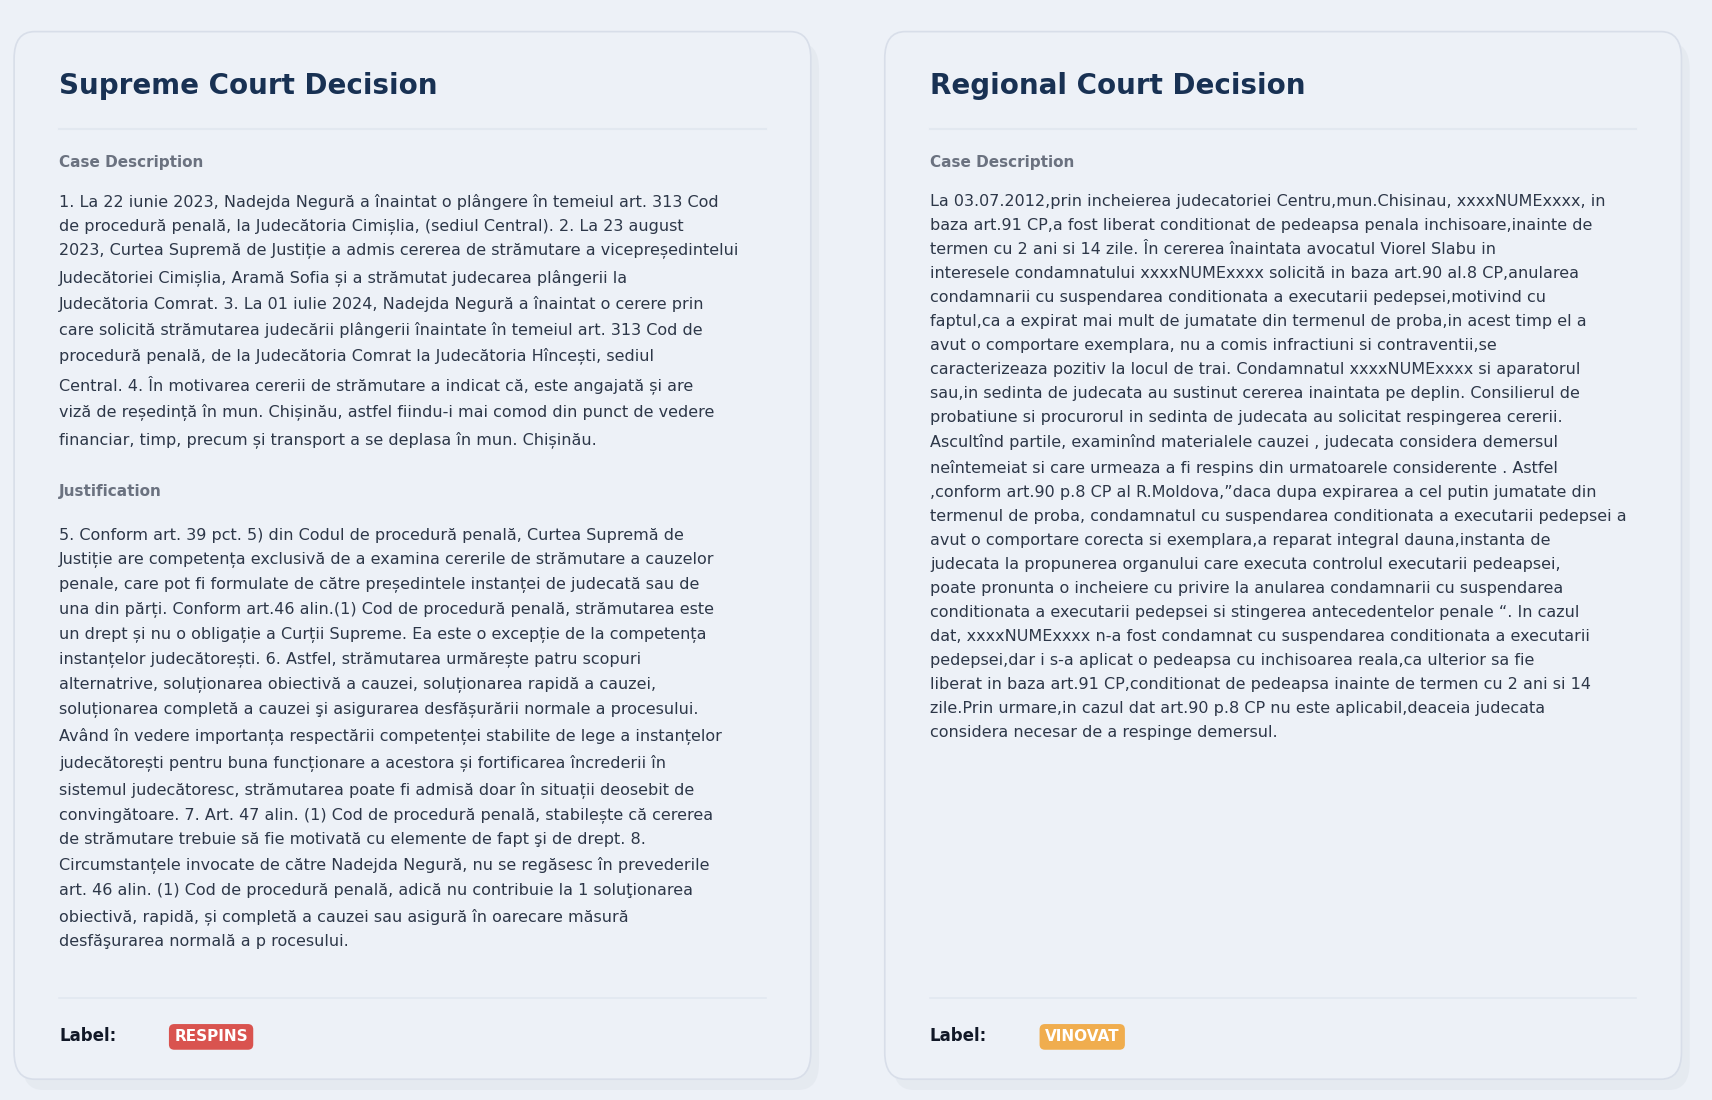

In [57]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from textwrap import fill

# =========================================================
# STYLE
# =========================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10
})

# =========================================================
# WRAP TEXT
# =========================================================
# IMPORTANT:
# smaller width = taller text
# larger width = text fills card better
#
# adjust between 65-85 depending on figure width
# =========================================================
supreme_wrapped = fill(supreme_text, width=82)
supreme_just_wrapped = fill(supreme_just, width=82)
regional_wrapped = fill(regional_text, width=82)

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 12),
    facecolor="#edf1f7"
)

# =========================================================
# COLORS
# =========================================================
PAGE_BG = "#ffffff"

CARD_BG = "#edf1f7"
CARD_BORDER = "#d8dee9"

TITLE_COLOR = "#183153"
TEXT_COLOR = "#2d3748"
SUBTITLE_COLOR = "#6b7280"

RED = "#d9534f"
ORANGE = "#f0ad4e"

# =========================================================
# CARD FUNCTION
# =========================================================
def draw_card(ax, title, content, label, label_color, just=None):

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # =====================================================
    # SHADOW
    # =====================================================
    shadow = FancyBboxPatch(
        (0.035, 0.02),
        0.93,
        0.93,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=0,
        facecolor="#cfd6df",
        alpha=0.25,
        zorder=1
    )

    ax.add_patch(shadow)

    # =====================================================
    # CARD
    # =====================================================
    card = FancyBboxPatch(
        (0.025, 0.03),
        0.93,
        0.93,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.2,
        edgecolor=CARD_BORDER,
        facecolor=CARD_BG,
        zorder=2
    )

    ax.add_patch(card)

    # =====================================================
    # TITLE
    # =====================================================
    ax.text(
        0.06,
        0.93,
        f"{title}",
        fontsize=20,
        fontweight="bold",
        color=TITLE_COLOR,
        va="center",
        zorder=5
    )

    # =====================================================
    # DIVIDER
    # =====================================================
    ax.plot(
        [0.06, 0.92],
        [0.89, 0.89],
        color="#e2e8f0",
        lw=1.5,
        zorder=5
    )

    # =====================================================
    # SUBTITLE
    # =====================================================
    ax.text(
        0.06,
        0.855,
        "Case Description",
        fontsize=11,
        color=SUBTITLE_COLOR,
        fontweight="bold",
        zorder=5
    )

    # =====================================================
    # MAIN TEXT
    # =====================================================
    ax.text(
        0.06,
        0.83,
        content,
        fontsize=11.5,
        color=TEXT_COLOR,
        va="top",
        ha="left",
        linespacing=1.75,
        zorder=5
    )

    # =====================================================
    # JUSTIFICATION
    # =====================================================
    if just:
        ax.text(
            0.06,
            0.55,
            "Justification",
            fontsize=11,
            color=SUBTITLE_COLOR,
            fontweight="bold",
            zorder=5
        )
        ax.text(
            0.06,
            0.52,
            just,
            fontsize=11.5,
            color=TEXT_COLOR,
            va="top",
            ha="left",
            linespacing=1.75,
            zorder=5
        )

    # =====================================================
    # BOTTOM DIVIDER
    # =====================================================
    ax.plot(
        [0.06, 0.92],
        [0.085, 0.085],
        color="#e2e8f0",
        lw=1.2
    )

    # =====================================================
    # LABEL
    # =====================================================
    ax.text(
        0.06,
        0.045,
        "Label:",
        fontsize=12,
        fontweight="bold",
        color="#111827"
    )

    ax.text(
        0.20,
        0.045,
        label,
        fontsize=11,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor=label_color,
            edgecolor="none"
        )
    )

# =========================================================
# DRAW PANELS
# =========================================================
draw_card(
    axes[0],
    "Supreme Court Decision",
    supreme_wrapped,
    "RESPINS",
    RED,
    supreme_just_wrapped
    # "⚖"
)

draw_card(
    axes[1],
    "Regional Court Decision",
    regional_wrapped,
    "VINOVAT",
    ORANGE
    # "🏛"
)

# =========================================================
# MAIN TITLE
# =========================================================
# fig.suptitle(
#     "Examples of Court Decisions from Judicial Datasets",
#     fontsize=28,
#     fontweight="bold",
#     color="#111827",
#     y=0.985
# )

# =========================================================
# LAYOUT
# =========================================================
plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.93,
    bottom=0.03,
    wspace=0.06
)

# =========================================================
# SAVE
# =========================================================
plt.savefig(
    "court_decisions_beautiful.png",
    dpi=400,
    bbox_inches="tight",
    facecolor=PAGE_BG
)

plt.show()

{'vinovat': 5244, 'nevinovat': 3626}
Total unique labels: 2


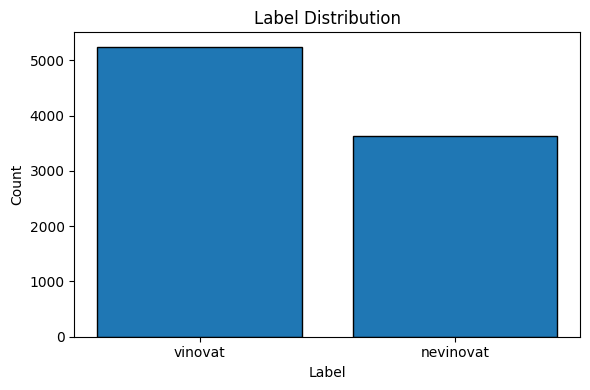

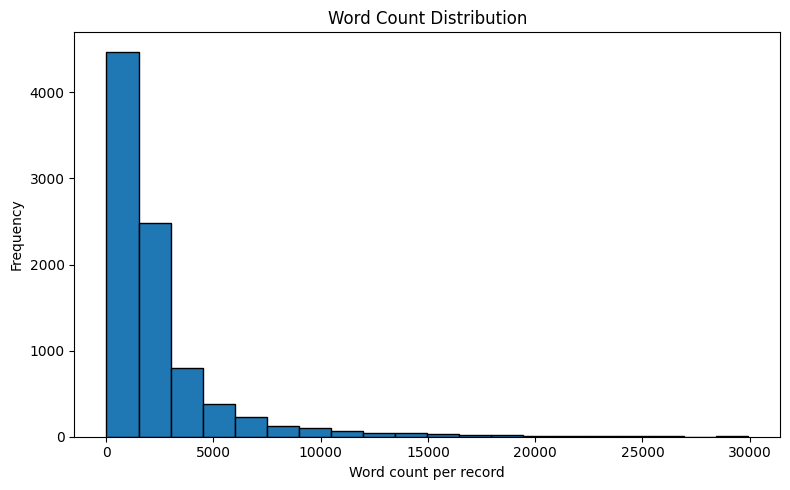

Total records: 8870
Mean: 2475.80
Median: 1502.00
Std (population): 3052.41
P90: 5366
P95: 8139
P99: 16244


In [ ]:
json_file = "data/regional-court-data.json"

with open(json_file, 'r') as f:
    data = json.load(f)

labels = [item['label'] for item in data]
label_counts = {}
for label in labels:
    label_counts[label] = label_counts.get(label, 0) + 1

print(label_counts)

print(f"Total unique labels: {len(label_counts)}")

plt.figure(figsize=(6, 4))
plt.bar(label_counts.keys(), label_counts.values(), edgecolor="black")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.tight_layout()
plt.show()
plt.close()

word_counts = []
for item in data:
    texts = [v for v in item.values() if isinstance(v, str)]
    combined = " ".join(texts)
    word_counts.append(len(combined.split()))

plt.figure(figsize=(8, 5))
plt.hist(word_counts, bins=20, edgecolor="black")
plt.xlabel("Word count per record")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")
plt.tight_layout()
plt.show()
plt.close() 

print(f"Total records: {len(data)}")

arr = np.array(word_counts)

mean = arr.mean()
median = np.median(arr)
std = arr.std(ddof=0)  # population std
p90, p95, p99 = np.percentile(arr, [90, 95, 99])

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std (population): {std:.2f}")
print(f"P90: {p90:.0f}")
print(f"P95: {p95:.0f}")
print(f"P99: {p99:.0f}")